In [4]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import MCMC, NUTS, Predictive
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Import helper function from the src directory
from src.inference.runner import run_parametric_mcmc

# Import models from the src directory
from src.models import (
    normal_model,
    contaminated_normal_model,
    student_t_model,
    bayesian_bootstrap_mean,
    bayesian_bootstrap_trimmed
)

# Import data from the data directory
data = jnp.load('../data/toy_dataset.npy')

In [2]:
print("Running Normal Model...")
mu_normal = run_parametric_mcmc(normal_model, data)["mu"]

print("Running Contaminated Normal Model...")
mu_contaminated = run_parametric_mcmc(contaminated_normal_model, data)["mu"]

print("Running Student-t Model...")
mu_student_t = run_parametric_mcmc(student_t_model, data)["mu"]

print("Running Bayesian Bootstrap (Mean)...")
predictive_bb_mean = Predictive(bayesian_bootstrap_mean, num_samples=4000)
mu_bb_mean = predictive_bb_mean(jax.random.PRNGKey(1), data)["mu"]

print("Running Bayesian Bootstrap (Trimmed)...")
predictive_bb_trim = Predictive(bayesian_bootstrap_trimmed, num_samples=4000)
mu_bb_trim = predictive_bb_trim(jax.random.PRNGKey(2), data)["mu"]

Running Normal Model...


sample: 100%|██████████| 5000/5000 [00:00<00:00, 5476.19it/s, 3 steps of size 6.05e-01. acc. prob=0.94]


Running Contaminated Normal Model...


sample: 100%|██████████| 5000/5000 [00:01<00:00, 4212.26it/s, 7 steps of size 2.73e-01. acc. prob=0.93] 


Running Student-t Model...


sample: 100%|██████████| 5000/5000 [00:01<00:00, 4846.95it/s, 7 steps of size 5.30e-01. acc. prob=0.86] 


Running Bayesian Bootstrap (Mean)...
Running Bayesian Bootstrap (Trimmed)...


/var/folders/mr/gyhq4nd5159cfdvmmd1l_d440000gn/T/ipykernel_93421/1368731461.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


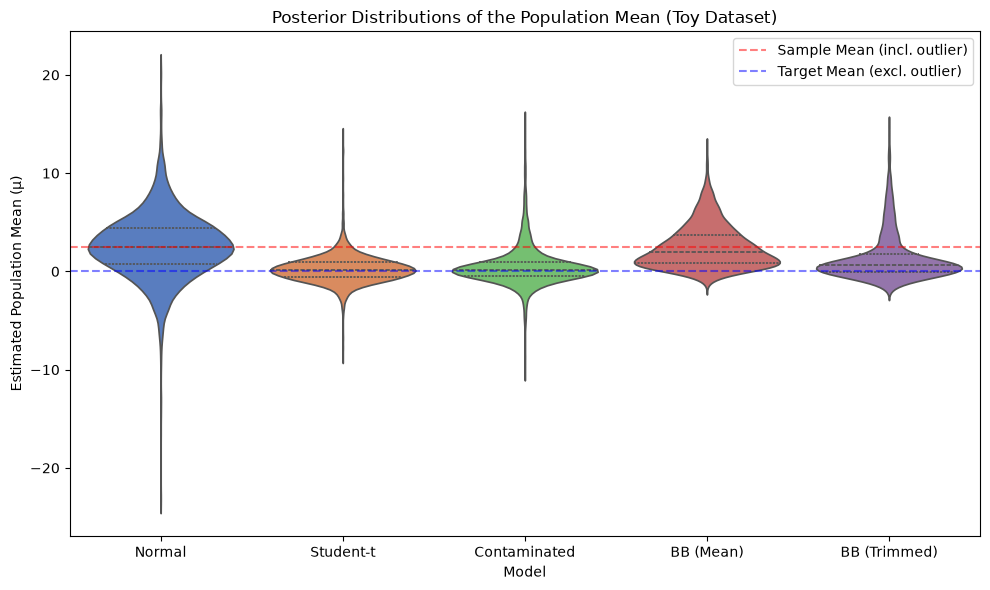

In [5]:
# Combine all samples into a Pandas DataFrame for easy plotting with Seaborn
df = pd.DataFrame({
    "Normal": mu_normal,
    "Student-t": mu_student_t,
    "Contaminated": mu_contaminated,
    "BB (Mean)": mu_bb_mean,
    "BB (Trimmed)": mu_bb_trim
})

# Melt the dataframe for Seaborn
df_melted = df.melt(var_name="Model", value_name="Posterior Mean Estimate")

# Create the plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    x="Model", 
    y="Posterior Mean Estimate", 
    data=df_melted, 
    inner="quartile", # Shows the median and interquartile range inside the violin
    palette="muted"
)

# Add a horizontal line representing the sample mean (~2.5) 
# and the robust mean without the outlier (0.0) for reference
plt.axhline(jnp.mean(data), color='red', linestyle='--', alpha=0.5, label="Sample Mean (incl. outlier)")
plt.axhline(0.0, color='blue', linestyle='--', alpha=0.5, label="Target Mean (excl. outlier)")

plt.title("Posterior Distributions of the Population Mean (Toy Dataset)")
plt.ylabel("Estimated Population Mean (μ)")
plt.legend()
plt.tight_layout()
plt.show()